# Project 1 — AI vs. Human Text Detection

This notebook satisfies the required assignment sections:

1. **Data Exploration & Preprocessing** — visualizations, class balance, cleaning, tokenization  
2. **Feature Engineering** — TF-IDF, Word2Vec embeddings, linguistic features, and feature-impact comparison  
3. **Model Training & Tuning** — six models with GridSearchCV, RandomizedSearchCV, or Keras tuning loops  
4. **Evaluation & Comparison** — accuracy tables, confusion matrices, ROC curves, AUC scores, speed comparison, and written analysis

Dataset labels:

- `0` = human-written text
- `1` = AI-written text


### Setup Notes

This cell imports the libraries for data processing, visualization, traditional ML, deep learning, and Word2Vec. It also sets a shared random seed so the results are repeatable.

In [1]:
# If needed, install packages first:
# !pip install pandas numpy matplotlib scikit-learn nltk gensim tensorflow openpyxl joblib

import os
import re
import time
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, ParameterSampler
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import TruncatedSVD

from collections import Counter
import joblib

# Deep learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Word2Vec
from gensim.models import Word2Vec

# Reproducibility and notebook speed settings
RANDOM_STATE = 42
CV_FOLDS = 3
N_JOBS = -1
FAST_MODE = True

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

2026-06-16 07:31:33.356337: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## I. Data Exploration & Preprocessing

This section loads the Excel dataset, checks the shape and missing values, visualizes class balance, inspects text length, cleans text, and tokenizes text.

### Load the Dataset

This loads the Excel training file into a DataFrame and confirms the number of rows, columns, and column names before any cleaning happens.

In [2]:
DATA_PATH = 'train_data with labels.xlsx'

# My notebook is in the same folder as my dataset, if yours is not change your DATA_PATH above.
df = pd.read_excel(DATA_PATH)

print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (8176, 2)
Columns: ['text', 'label']


,text,label
0,Councils are debating if building housing area...,0
1,While reading the succesful people's lifes you...,0
2,"Finally, she felt that the robotics unit was i...",1
3,Since sigmoid can be viewed as a special 2clas...,1
4,In this essay we will talk about why in so man...,0


### Check Data Quality

This verifies data types, missing values, and label counts. These checks help catch problems before model training.

In [4]:
# Basic checks

print(df.info())
print('Missing values:')
print(df.isna().sum())
print('Label counts:')
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8176 entries, 0 to 8175
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8176 non-null   object
 1   label   8176 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 127.9+ KB
None
Missing values:
text     0
label    0
dtype: int64
Label counts:
label
0    4088
1    4088
Name: count, dtype: int64


### Clean Rows

This removes missing and duplicate text entries. Removing duplicates is important because duplicate text can leak information between training and testing sets.

In [5]:
# Drop missing/duplicate rows if present

df = df.dropna(subset=['text', 'label']).copy()
df = df.drop_duplicates(subset=['text']).copy()
df['label'] = df['label'].astype(int)

print('Cleaned dataset shape:', df.shape)
print(df['label'].value_counts())

Cleaned dataset shape: (8169, 2)
label
1    4085
0    4084
Name: count, dtype: int64


### Visualize Class Balance

This shows whether the dataset has a similar number of Human and AI examples. A large imbalance could bias model performance.

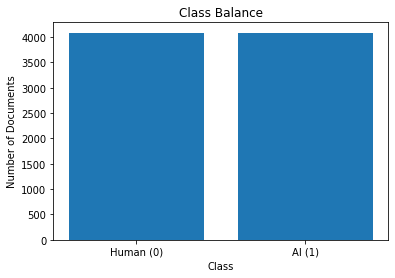

In [6]:
# Visualize class balance

label_counts = df['label'].value_counts().sort_index()
label_names = ['Human (0)', 'AI (1)']

plt.figure(figsize=(6, 4))
plt.bar(label_names, label_counts.values)
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Number of Documents')
plt.show()

### Explore Text Length

This creates simple length measurements. Length-related patterns can sometimes help distinguish AI-generated writing from human writing.

In [7]:
# Text length exploration

df['char_count'] = df['text'].astype(str).str.len()
df['word_count'] = df['text'].astype(str).str.split().str.len()

df[['char_count', 'word_count']].describe()

,char_count,word_count
count,8169.000000,8169.000000
mean,2108.356102,325.278859
std,503.039753,61.221138
min,400.000000,62.000000
25%,1728.000000,287.000000
50%,2138.000000,335.000000
75%,2486.000000,372.000000
max,4827.000000,687.000000


### Compare Word Count Distributions

This histogram compares document length by class so we can see whether Human and AI texts have noticeably different length patterns.

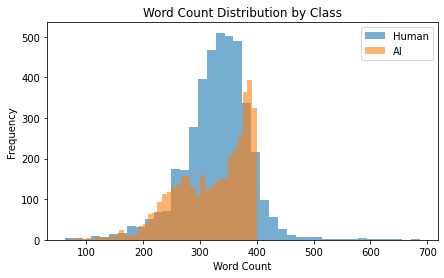

In [8]:
# Word count visualization

plt.figure(figsize=(7, 4))
plt.hist(df.loc[df['label'] == 0, 'word_count'], bins=40, alpha=0.6, label='Human')
plt.hist(df.loc[df['label'] == 1, 'word_count'], bins=40, alpha=0.6, label='AI')
plt.title('Word Count Distribution by Class')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Clean and Tokenize Text

This creates `clean_text` for vectorization and `tokens` for word-frequency analysis. The original text is preserved for linguistic features.

In [9]:
# Text cleaning: lowercase, remove punctuation, remove numbers, remove stop words

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)      # remove urls
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep letters and spaces only
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

def tokenize_text(text):
    return clean_text(text).split()

df['clean_text'] = df['text'].apply(clean_text)
df['tokens'] = df['text'].apply(tokenize_text)

df[['text', 'clean_text', 'tokens', 'label']].head()

,text,clean_text,tokens,label
0,Councils are debating if building housing area...,councils debating building housing areas expan...,"[councils, debating, building, housing, areas,...",0
1,While reading the succesful people's lifes you...,reading succesful people lifes probably ones t...,"[reading, succesful, people, lifes, probably, ...",0
2,"Finally, she felt that the robotics unit was i...",finally felt robotics unit important engage st...,"[finally, felt, robotics, unit, important, eng...",1
3,Since sigmoid can be viewed as a special 2clas...,sigmoid viewed special class case case softmax...,"[sigmoid, viewed, special, class, case, case, ...",1
4,In this essay we will talk about why in so man...,essay talk countries students prefer choose sc...,"[essay, talk, countries, students, prefer, cho...",0


### Distinctive Word Heatmap

I choose to use a heatmap because I felt is was a more measurable visual. It shows actual word counts for the words that differ most between Human and AI samples.

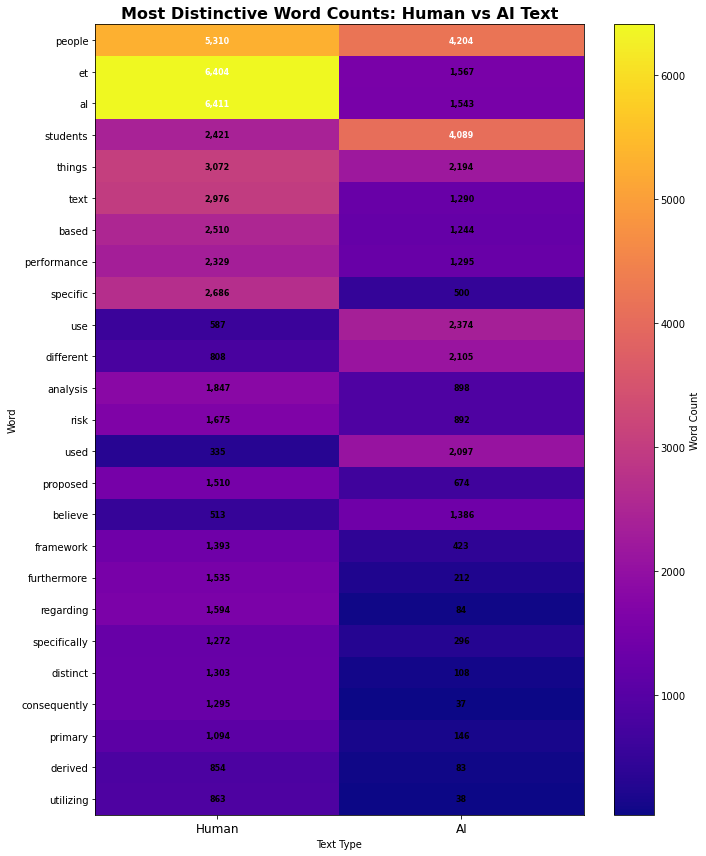

In [10]:
# Collect tokens for Human and AI text

human_tokens = []
ai_tokens = []

for tokens in df.loc[df['label'] == 0, 'tokens']:
    human_tokens.extend(tokens)

for tokens in df.loc[df['label'] == 1, 'tokens']:
    ai_tokens.extend(tokens)

# Count word frequencies
human_counts = Counter(human_tokens)
ai_counts = Counter(ai_tokens)

# Find words with the largest count differences between Human and AI
word_differences = {}

all_words = set(human_counts.keys()).union(ai_counts.keys())

for word in all_words:
    human_count = human_counts.get(word, 0)
    ai_count = ai_counts.get(word, 0)
    word_differences[word] = abs(human_count - ai_count)

# Select the top 25 most different words
top_words = [
    word for word, difference in
    sorted(word_differences.items(), key=lambda x: x[1], reverse=True)[:25]
]

# Build heatmap dataframe using actual counts
heatmap_df = pd.DataFrame(
    {
        "Human": [human_counts.get(word, 0) for word in top_words],
        "AI": [ai_counts.get(word, 0) for word in top_words]
    },
    index=top_words
)

# Sort by total frequency for cleaner display
heatmap_df["Total"] = heatmap_df["Human"] + heatmap_df["AI"]
heatmap_df = heatmap_df.sort_values("Total", ascending=False)
heatmap_df = heatmap_df.drop(columns=["Total"])

# Create heatmap
plt.figure(figsize=(10, 12))

im = plt.imshow(
    heatmap_df,
    aspect="auto",
    cmap="plasma"
)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label("Word Count")

# Axis labels
plt.xticks([0, 1], ["Human", "AI"], fontsize=12)
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index, fontsize=10)

# Add count labels inside each heatmap cell
max_val = heatmap_df.values.max()

for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        value = heatmap_df.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="white" if value > max_val * 0.5 else "black"
        )

# Titles and formatting
plt.title(
    "Most Distinctive Word Counts: Human vs AI Text",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Text Type")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

## Train/Test Split (80/20)

The same split is used across models so the model comparisons are fair.

### Create the Train/Test Split

The split is stratified so both training and testing sets keep approximately the same Human/AI label balance.

In [11]:
X = df[['text', 'clean_text']].copy()
y = df['label'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])
print('Train class balance:', y_train.value_counts(normalize=True).to_dict())
print('Test class balance:', y_test.value_counts(normalize=True).to_dict())

Training rows: 6535
Testing rows: 1634
Train class balance: {1: 0.5000765110941087, 0: 0.49992348890589133}
Test class balance: {0: 0.5, 1: 0.5}


## II. Feature Engineering

This notebook compares three feature groups:

1. **TF-IDF** — word importance based on frequency and distinctiveness  
2. **Word2Vec embeddings** — dense semantic vectors trained from the dataset  
3. **Linguistic features** — handcrafted writing-style features such as word count, sentence length, punctuation, and vocabulary richness

### Linguistic Feature

This custom transformer creates writing-style features such as sentence length, punctuation usage, capitalization, and vocabulary diversity.

In [12]:
class LinguisticFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Create simple writing-style features from raw text.

    These features are intentionally separate from TF-IDF. TF-IDF captures what
    words are used, while these features capture how the text is written.
    """

    def fit(self, X, y=None):
        # No learned parameters are needed, but fit is required for sklearn pipelines.
        return self

    def transform(self, X):
        # Accept DataFrames, Series, lists, or arrays and convert everything to text.
        if isinstance(X, pd.DataFrame):
            texts = X.iloc[:, 0].astype(str).tolist()
        elif isinstance(X, pd.Series):
            texts = X.astype(str).tolist()
        else:
            texts = [str(x) for x in X]

        rows = []
        for text in texts:
            # Correct word-boundary regex. The previous version used a backspace
            # character by accident, which caused word counts to be incorrect.
            words = re.findall(r'\b\w+\b', text.lower())
            sentences = re.split(r'[.!?]+', text)
            sentences = [s for s in sentences if s.strip()]
            unique_words = set(words)

            word_count = len(words)
            char_count = len(text)
            sentence_count = max(len(sentences), 1)
            avg_word_len = np.mean([len(w) for w in words]) if words else 0
            avg_sentence_len = word_count / sentence_count
            type_token_ratio = len(unique_words) / word_count if word_count else 0
            punctuation_count = sum(1 for c in text if c in string.punctuation)
            comma_count = text.count(',')
            exclamation_count = text.count('!')
            question_count = text.count('?')
            uppercase_ratio = sum(1 for c in text if c.isupper()) / max(char_count, 1)

            rows.append([
                char_count, word_count, sentence_count, avg_word_len,
                avg_sentence_len, type_token_ratio, punctuation_count,
                comma_count, exclamation_count, question_count, uppercase_ratio
            ])

        return np.array(rows)

ling_feature_names = [
    'char_count', 'word_count', 'sentence_count', 'avg_word_len',
    'avg_sentence_len', 'type_token_ratio', 'punctuation_count',
    'comma_count', 'exclamation_count', 'question_count', 'uppercase_ratio'
]

# Quick preview to confirm the feature extractor is producing useful values.
ling_extractor = LinguisticFeatureExtractor()
ling_sample = pd.DataFrame(
    ling_extractor.transform(X_train['text'].head()), columns=ling_feature_names
)
ling_sample

,char_count,word_count,sentence_count,avg_word_len,avg_sentence_len,type_token_ratio,punctuation_count,comma_count,exclamation_count,question_count,uppercase_ratio
0,2593.0,386.0,17.0,5.608808,22.705882,0.500000,37.0,15.0,0.0,0.0,0.011184
1,2475.0,369.0,35.0,5.338753,10.542857,0.615176,138.0,18.0,0.0,2.0,0.033939
2,1606.0,269.0,12.0,4.881041,22.416667,0.494424,33.0,12.0,0.0,0.0,0.008717
3,2355.0,350.0,28.0,5.608571,12.500000,0.511429,42.0,11.0,0.0,0.0,0.022505
4,2468.0,378.0,23.0,5.365079,16.434783,0.539683,51.0,18.0,0.0,0.0,0.026742


### Word2Vec Embedding

This trains Word2Vec on the training data and turns each document into an average word-vector representation for embedding-based comparison.

In [13]:
# Word2Vec feature creation
# Each document becomes the average of its word vectors.

train_tokens = X_train['clean_text'].apply(lambda x: x.split()).tolist()
test_tokens = X_test['clean_text'].apply(lambda x: x.split()).tolist()

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

def document_vector(tokens, model, vector_size=100):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

X_train_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in train_tokens])
X_test_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in test_tokens])

print('Word2Vec train shape:', X_train_w2v.shape)
print('Word2Vec test shape:', X_test_w2v.shape)

Word2Vec train shape: (6535, 100)
Word2Vec test shape: (1634, 100)


### Evaluation Helpers

These helper functions make every model report the same metrics and prevent duplicate result rows if a model cell is rerun.

In [14]:
# Store all model results in one place.
# The helper below replaces an existing row when the same model/feature-set pair
# is evaluated again. This prevents duplicate rows if a notebook cell is rerun.
results = []
roc_data = {}
training_times = {}
# tuning_results stores the best hyperparameters and the search method used for each model.
tuning_results = []

def get_scores(model, X_data):
    """Return scores for ROC/AUC using probabilities when available, otherwise margins."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X_data)
    raise ValueError('Model does not provide probabilities or decision scores.')


def upsert_result(metrics):
    """Add a result or replace the old result for the same Model + Feature Set."""
    global results
    results = [
        row for row in results
        if not (
            row['Model'] == metrics['Model']
            and row['Feature Set'] == metrics['Feature Set']
        )
    ]
    results.append(metrics)


def record_tuning_result(model_name, search_method, best_params, best_score=None):
    """Store tuning details so the final notebook clearly documents how each model was tuned."""
    tuning_results.append({
        'Model': model_name,
        'Search Method': search_method,
        'Best Parameters': str(best_params),
        'Best Validation/CV Score': best_score
    })


def evaluate_model(name, model, X_data, y_true, feature_set, training_time=None):
    """Evaluate a scikit-learn model and store consistent metrics/ROC data."""
    y_pred = model.predict(X_data)
    y_score = get_scores(model, X_data)

    metrics = {
        'Model': name,
        'Feature Set': feature_set,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_score),
        'Training Time Seconds': training_time
    }
    upsert_result(metrics)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_data[f'{name} — {feature_set}'] = {
        'fpr': fpr,
        'tpr': tpr,
        'auc': metrics['AUC']
    }

    print(f'{name} ({feature_set})')
    print(classification_report(y_true, y_pred, target_names=['Human', 'AI'], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])
    disp.plot()
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

    return metrics


def evaluate_keras_model(name, model, X_data, y_true, feature_set, training_time=None):
    """Evaluate a Keras binary classifier using the same metric structure."""
    y_score = model.predict(X_data, verbose=0).ravel()
    y_pred = (y_score >= 0.5).astype(int)

    metrics = {
        'Model': name,
        'Feature Set': feature_set,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_score),
        'Training Time Seconds': training_time
    }
    upsert_result(metrics)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_data[f'{name} — {feature_set}'] = {
        'fpr': fpr,
        'tpr': tpr,
        'auc': metrics['AUC']
    }

    print(f'{name} ({feature_set})')
    print(classification_report(y_true, y_pred, target_names=['Human', 'AI'], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])
    disp.plot()
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

    return metrics

## III. Model Training & Tuning

This section trains all six required classifiers and includes hyperparameter tuning for each model.

- **SVM** uses `GridSearchCV`.
- **Decision Tree** uses `GridSearchCV`.
- **AdaBoost** uses `RandomizedSearchCV`.
- **FNN, LSTM, and CNN** use a RandomSearch-style tuning loop. This is the neural-network equivalent of RandomSearch: the notebook tests multiple parameter combinations, evaluates each one on a validation split, and keeps the best-performing configuration.

This approach satisfies the requirement to train all six models and use GridSearch or RandomSearch for hyperparameter tuning while keeping the notebook practical to run on a normal laptop.

### Hyperparameter Tuning Strategy

The assignment requires all six models to be trained and tuned. For the traditional machine learning models, the notebook uses scikit-learn's built-in search tools. For the deep learning models, the notebook uses an explicit RandomSearch-style process instead of adding another dependency such as KerasTuner. Each neural-network trial builds a fresh model, trains it with early stopping, records validation accuracy, and saves the parameter set that performs best.

This makes the tuning process visible in the notebook and avoids treating the neural networks as untuned default models.

### Feature Set A: TF-IDF Only

This is the recommended baseline representation.

### TF-IDF Feature Setup

TF-IDF converts words and two-word phrases into numeric features based on their importance in the dataset.

In [15]:
# TF-IDF vectorizer used inside model pipelines.
# Limiting max_features keeps the notebook faster while still retaining the most useful terms.
base_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

### Feature Set B: TF-IDF + Linguistic Features

This tests whether writing-style features improve performance beyond words alone.

### Combine TF-IDF and Linguistic Features

This uses a `ColumnTransformer` to process cleaned text through TF-IDF and raw text through the linguistic feature extractor.

In [16]:
# Combine two different feature types:
# 1. TF-IDF from clean_text captures vocabulary and phrase patterns.
# 2. Linguistic features from raw text capture writing style and structure.
combined_features = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95), 'clean_text'),
        ('ling', Pipeline([
            ('features', LinguisticFeatureExtractor()),
            ('scale', StandardScaler())
        ]), ['text'])
    ],
    remainder='drop'
)

### ML Model 1 — Support Vector Machine with GridSearchCV

### Train the SVM

The SVM uses TF-IDF plus linguistic features. `LinearSVC` is used because it is much faster for sparse text features than a kernel SVM.

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best SVM parameters: {'svm__C': 2, 'svm__class_weight': None}
Best CV F1: 0.9668716137969041
SVM (TF-IDF + Linguistic)
              precision    recall  f1-score   support

       Human       0.97      0.98      0.97       817
          AI       0.98      0.97      0.97       817

    accuracy                           0.97      1634
   macro avg       0.97      0.97      0.97      1634
weighted avg       0.97      0.97      0.97      1634



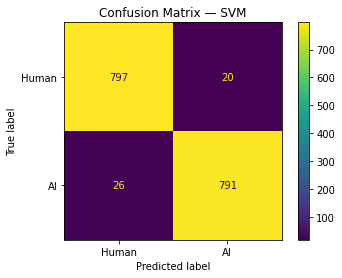

{'Model': 'SVM',
 'Feature Set': 'TF-IDF + Linguistic',
 'Accuracy': 0.9718482252141983,
 'Precision': 0.9753390875462392,
 'Recall': 0.9681762545899633,
 'F1': 0.9717444717444718,
 'AUC': 0.9956358831381491,
 'Training Time Seconds': 69.86387419700623}

In [17]:
# -----------------------------------------------------------------------------
# Support Vector Machine (SVM) with GridSearchCV
# -----------------------------------------------------------------------------
# This model uses the combined feature set: TF-IDF text features plus linguistic
# writing-style features. LinearSVC is used because it is much faster than a
# kernel SVC for high-dimensional sparse text data.
#
# GridSearchCV tests multiple C and class_weight values using cross-validation.
# The best parameter combination is selected using F1-score because F1 balances
# precision and recall for the AI-vs-Human classification problem.
svm_pipeline = Pipeline([
    ('features', combined_features),
    ('svm', LinearSVC(
        random_state=RANDOM_STATE,
        max_iter=20000,      # gives Liblinear more time to converge
        tol=1e-3,            # slightly relaxed tolerance for faster convergence
        dual=False           # recommended when n_samples > n_features after preprocessing
    ))
])

svm_params = {
    'svm__C': [0.25, 0.5, 1, 2, 5],
    'svm__class_weight': [None, 'balanced']
}

start = time.time()
svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_params,
    scoring='f1',
    cv=CV_FOLDS,
    n_jobs=N_JOBS,
    verbose=1
)
svm_grid.fit(X_train, y_train)
svm_time = time.time() - start

print('Best SVM parameters:', svm_grid.best_params_)
print('Best CV F1:', svm_grid.best_score_)
record_tuning_result('SVM', 'GridSearchCV', svm_grid.best_params_, svm_grid.best_score_)
evaluate_model('SVM', svm_grid.best_estimator_, X_test, y_test, 'TF-IDF + Linguistic', svm_time)

### ML Model 2 — Decision Tree with GridSearchCV

### Train the Decision Tree

The decision tree is tuned with GridSearchCV. The depth and leaf settings help control overfitting.

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Decision Tree parameters: {'tree__max_depth': 10, 'tree__min_samples_leaf': 4, 'tree__min_samples_split': 10}
Best CV F1: 0.8941085892217949
Decision Tree (TF-IDF + Linguistic)
              precision    recall  f1-score   support

       Human       0.92      0.89      0.91       817
          AI       0.89      0.93      0.91       817

    accuracy                           0.91      1634
   macro avg       0.91      0.91      0.91      1634
weighted avg       0.91      0.91      0.91      1634



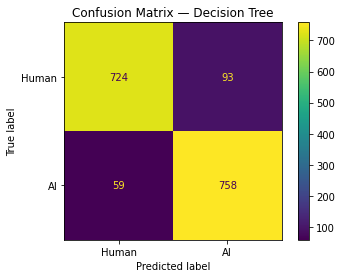

{'Model': 'Decision Tree',
 'Feature Set': 'TF-IDF + Linguistic',
 'Accuracy': 0.9069767441860465,
 'Precision': 0.8907168037602821,
 'Recall': 0.9277845777233782,
 'F1': 0.9088729016786571,
 'AUC': 0.923863913862251,
 'Training Time Seconds': 200.36681199073792}

In [18]:
tree_pipeline = Pipeline([
    ('features', combined_features),
    ('tree', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# A smaller grid keeps the decision tree section quick while still testing depth/leaf complexity.
tree_params = {
    'tree__max_depth': [10, 20, None],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4]
}

start = time.time()
tree_grid = GridSearchCV(
    tree_pipeline,
    tree_params,
    scoring='f1',
    cv=CV_FOLDS,
    n_jobs=N_JOBS,
    verbose=1
)
tree_grid.fit(X_train, y_train)
tree_time = time.time() - start

print('Best Decision Tree parameters:', tree_grid.best_params_)
print('Best CV F1:', tree_grid.best_score_)
record_tuning_result('Decision Tree', 'GridSearchCV', tree_grid.best_params_, tree_grid.best_score_)
evaluate_model('Decision Tree', tree_grid.best_estimator_, X_test, y_test, 'TF-IDF + Linguistic', tree_time)

### Decision Tree Visualization

Only the top levels are shown because the full tree is too large when using TF-IDF features.

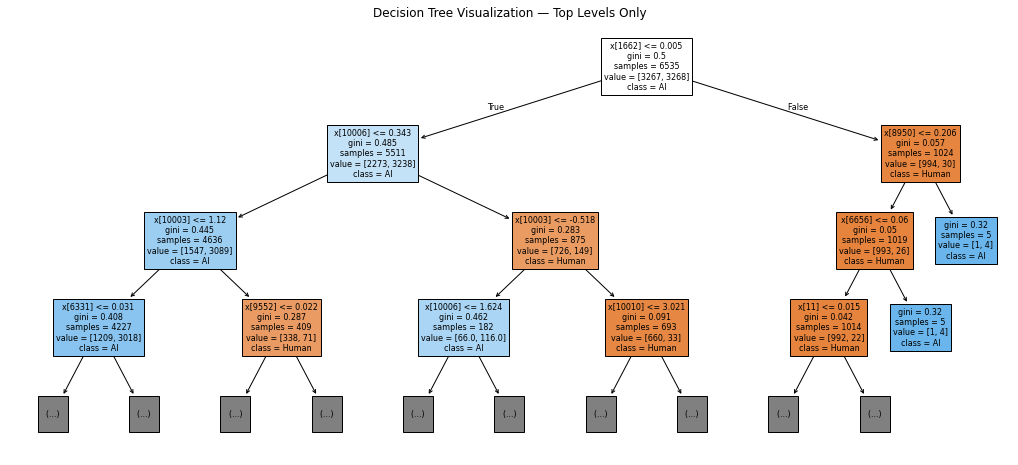

In [19]:
# Optional: visualize the trained decision tree.
# Because the full TF-IDF tree is large, I'm only showing the top levels.
plt.figure(figsize=(18, 8))
plot_tree(
    tree_grid.best_estimator_.named_steps['tree'],
    max_depth=3,
    filled=True,
    class_names=['Human', 'AI']
)
plt.title('Decision Tree Visualization — Top Levels Only')
plt.show()

### ML Model 3 — AdaBoost with RandomizedSearchCV

### Train AdaBoost

AdaBoost is tuned with RandomizedSearchCV to reduce runtime while still testing several parameter combinations.

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best AdaBoost parameters: {'ada__n_estimators': 100, 'ada__learning_rate': 1.0}
Best CV F1: 0.9197615629068555
AdaBoost (TF-IDF + Linguistic)
              precision    recall  f1-score   support

       Human       0.94      0.93      0.93       817
          AI       0.93      0.94      0.93       817

    accuracy                           0.93      1634
   macro avg       0.93      0.93      0.93      1634
weighted avg       0.93      0.93      0.93      1634



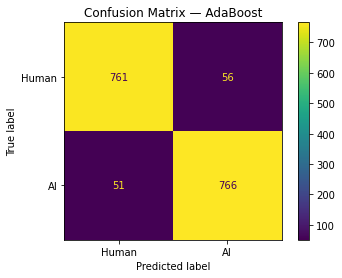

{'Model': 'AdaBoost',
 'Feature Set': 'TF-IDF + Linguistic',
 'Accuracy': 0.934516523867809,
 'Precision': 0.9318734793187348,
 'Recall': 0.9375764993880049,
 'F1': 0.9347162904209884,
 'AUC': 0.9835660213127108,
 'Training Time Seconds': 111.22167491912842}

In [20]:
ada_pipeline = Pipeline([
    ('features', combined_features),
    ('ada', AdaBoostClassifier(random_state=RANDOM_STATE))
])

ada_params = {
    'ada__n_estimators': [50, 100, 200],
    'ada__learning_rate': [0.05, 0.1, 0.5, 1.0]
}

start = time.time()
ada_search = RandomizedSearchCV(
    ada_pipeline,
    ada_params,
    n_iter=6,
    scoring='f1',
    cv=CV_FOLDS,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1
)
ada_search.fit(X_train, y_train)
ada_time = time.time() - start

print('Best AdaBoost parameters:', ada_search.best_params_)
print('Best CV F1:', ada_search.best_score_)
record_tuning_result('AdaBoost', 'RandomizedSearchCV', ada_search.best_params_, ada_search.best_score_)
evaluate_model('AdaBoost', ada_search.best_estimator_, X_test, y_test, 'TF-IDF + Linguistic', ada_time)

### Embedding Comparison Model — SVM with Word2Vec

This model is used to satisfy and demonstrate the TF-IDF vs. embedding comparison requirement. Word2Vec embeddings are compared using the same SVM classifier.

### Compare with Word2Vec

This SVM uses Word2Vec document embeddings so the notebook can compare TF-IDF against word embeddings.

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Word2Vec SVM parameters: {'svm__C': 2, 'svm__kernel': 'rbf'}
Best CV F1: 0.9554430386144284
SVM with Word2Vec (Word2Vec Embeddings)
              precision    recall  f1-score   support

       Human       0.94      0.95      0.95       817
          AI       0.95      0.94      0.94       817

    accuracy                           0.94      1634
   macro avg       0.94      0.94      0.94      1634
weighted avg       0.94      0.94      0.94      1634



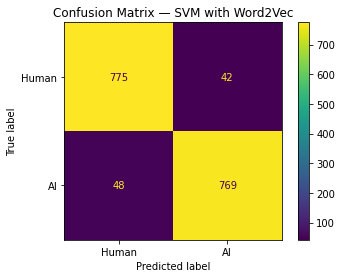

{'Model': 'SVM with Word2Vec',
 'Feature Set': 'Word2Vec Embeddings',
 'Accuracy': 0.944920440636475,
 'Precision': 0.9482120838471023,
 'Recall': 0.9412484700122399,
 'F1': 0.9447174447174447,
 'AUC': 0.9890664864889158,
 'Training Time Seconds': 8.997811317443848}

In [21]:
# Word2Vec comparison model.
# probability=False avoids the expensive probability calibration step; ROC/AUC uses decision_function.
w2v_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(probability=False, random_state=RANDOM_STATE, cache_size=1000))
])

w2v_params = {
    'svm__C': [0.5, 1, 2],
    'svm__kernel': ['linear', 'rbf']
}

start = time.time()
w2v_grid = GridSearchCV(
    w2v_pipeline,
    w2v_params,
    scoring='f1',
    cv=CV_FOLDS,
    n_jobs=N_JOBS,
    verbose=1
)
w2v_grid.fit(X_train_w2v, y_train)
w2v_time = time.time() - start

print('Best Word2Vec SVM parameters:', w2v_grid.best_params_)
print('Best CV F1:', w2v_grid.best_score_)
record_tuning_result('SVM with Word2Vec', 'GridSearchCV', w2v_grid.best_params_, w2v_grid.best_score_)
evaluate_model('SVM with Word2Vec', w2v_grid.best_estimator_, X_test_w2v, y_test, 'Word2Vec Embeddings', w2v_time)

### DL Model 1 — Feedforward Neural Network with Tuning

The FNN uses reduced TF-IDF features. `TruncatedSVD` reduces the large sparse TF-IDF matrix into a smaller dense matrix that a neural network can train on efficiently.

### Prepare Dense Features for the FNN

The FNN needs dense numeric arrays, so TF-IDF is reduced using TruncatedSVD before neural network training.

In [22]:
# Prepare TF-IDF + SVD features for the FNN

fnn_tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, max_df=0.95)
X_train_tfidf = fnn_tfidf.fit_transform(X_train['clean_text'])
X_test_tfidf = fnn_tfidf.transform(X_test['clean_text'])

svd = TruncatedSVD(n_components=300, random_state=42)
X_train_fnn = svd.fit_transform(X_train_tfidf)
X_test_fnn = svd.transform(X_test_tfidf)

scaler = StandardScaler()
X_train_fnn = scaler.fit_transform(X_train_fnn)
X_test_fnn = scaler.transform(X_test_fnn)

print(X_train_fnn.shape, X_test_fnn.shape)

(6535, 300) (1634, 300)


### Train the Feedforward Neural Network

This model learns from the reduced TF-IDF/SVD features and uses early stopping to avoid unnecessary training.

FNN RandomSearch trial 1/4: {'learning_rate': 0.0005, 'hidden_units': 256, 'dropout_rate': 0.4, 'batch_size': 64}
Validation accuracy: 0.9403213262557983
FNN RandomSearch trial 2/4: {'learning_rate': 0.0005, 'hidden_units': 64, 'dropout_rate': 0.4, 'batch_size': 32}
Validation accuracy: 0.9273144602775574
FNN RandomSearch trial 3/4: {'learning_rate': 0.001, 'hidden_units': 128, 'dropout_rate': 0.3, 'batch_size': 64}
Validation accuracy: 0.9426167011260986
FNN RandomSearch trial 4/4: {'learning_rate': 0.001, 'hidden_units': 64, 'dropout_rate': 0.4, 'batch_size': 64}
Validation accuracy: 0.9265493750572205
Best FNN parameters: {'learning_rate': 0.001, 'hidden_units': 128, 'dropout_rate': 0.3, 'batch_size': 64}
Best FNN validation accuracy: 0.9426167011260986
FNN (TF-IDF/SVD Dense Features)
              precision    recall  f1-score   support

       Human       0.93      0.92      0.92       817
          AI       0.92      0.93      0.92       817

    accuracy                         

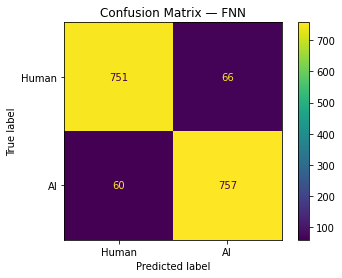

{'Model': 'FNN',
 'Feature Set': 'TF-IDF/SVD Dense Features',
 'Accuracy': 0.9228886168910648,
 'Precision': 0.9198055893074119,
 'Recall': 0.9265605875152999,
 'F1': 0.9231707317073171,
 'AUC': 0.9809105468404723,
 'Training Time Seconds': 16.224119186401367}

In [23]:
# -----------------------------------------------------------------------------
# Feedforward Neural Network (FNN) with RandomSearch-style tuning
# -----------------------------------------------------------------------------
# The FNN uses dense TF-IDF/SVD features instead of sparse TF-IDF features.
# Neural networks require fixed-size dense numeric arrays, so the earlier SVD step
# compressed the TF-IDF representation into a manageable number of components.
#
# Instead of installing KerasTuner, this notebook performs a visible RandomSearch:
# 1. Define a hyperparameter search space.
# 2. Randomly sample a small number of combinations.
# 3. Train one fresh model per combination.
# 4. Keep the model with the best validation accuracy.

def build_fnn(input_dim, hidden_units=128, dropout_rate=0.3, learning_rate=0.001):
    """Build a feedforward neural network for dense TF-IDF/SVD features."""
    model = Sequential([
        Dense(hidden_units, activation='relu', input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(hidden_units // 2, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

fnn_param_space = {
    'hidden_units': [64, 128, 256],
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [0.001, 0.0005],
    'batch_size': [32, 64]
}

# FAST_MODE keeps the notebook practical. Set FAST_MODE = False at the top of the
# notebook to test more combinations.
fnn_trials = 4 if FAST_MODE else 8
fnn_param_list = list(ParameterSampler(fnn_param_space, n_iter=fnn_trials, random_state=RANDOM_STATE))

best_fnn = None
best_fnn_val = -1
best_fnn_params = None
start = time.time()

for trial_number, params in enumerate(fnn_param_list, start=1):
    params = dict(params)  # copy because batch_size is removed before calling build_fnn
    print(f"FNN RandomSearch trial {trial_number}/{len(fnn_param_list)}: {params}")

    batch_size = params.pop('batch_size')
    model = build_fnn(X_train_fnn.shape[1], **params)

    history = model.fit(
        X_train_fnn, y_train,
        validation_split=0.2,
        epochs=8,
        batch_size=batch_size,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    )

    val_acc = max(history.history['val_accuracy'])
    trial_params = dict(params)
    trial_params['batch_size'] = batch_size
    print('Validation accuracy:', val_acc)

    if val_acc > best_fnn_val:
        best_fnn_val = val_acc
        best_fnn = model
        best_fnn_params = trial_params

fnn_time = time.time() - start
print('Best FNN parameters:', best_fnn_params)
print('Best FNN validation accuracy:', best_fnn_val)
record_tuning_result('FNN', 'RandomSearch-style Keras loop', best_fnn_params, best_fnn_val)
evaluate_keras_model('FNN', best_fnn, X_test_fnn, y_test, 'TF-IDF/SVD Dense Features', fnn_time)

### Prepare Tokenized Sequences for LSTM and CNN

### Prepare Sequences for LSTM and CNN

The LSTM and CNN need tokenized, padded sequences so every document has the same input length.

In [24]:
# Tokenized sequences are used by the LSTM and CNN models.
# MAX_LEN limits each document to a fixed length for faster neural-network training.
MAX_WORDS = 20000
MAX_LEN = 200
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(X_train['clean_text'])
X_test_seq = tokenizer.texts_to_sequences(X_test['clean_text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(X_train_pad.shape, X_test_pad.shape)

(6535, 200) (1634, 200)


### DL Model 2 — LSTM with Tuning

### Train the LSTM

The LSTM reads text as a sequence and learns word-order patterns that may separate Human and AI writing.

LSTM RandomSearch trial 1/3: {'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32}
Validation accuracy: 0.8538638353347778
LSTM RandomSearch trial 2/3: {'lstm_units': 64, 'learning_rate': 0.001, 'dropout_rate': 0.4, 'batch_size': 64}
Validation accuracy: 0.7551645040512085
LSTM RandomSearch trial 3/3: {'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32}
Validation accuracy: 0.8071920275688171
Best LSTM parameters: {'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32}
Best LSTM validation accuracy: 0.8538638353347778
LSTM (Tokenized Sequences)
              precision    recall  f1-score   support

       Human       0.79      0.95      0.86       817
          AI       0.94      0.75      0.83       817

    accuracy                           0.85      1634
   macro avg       0.86      0.85      0.85      1634
weighted avg       0.86      0.85      0.85      1634



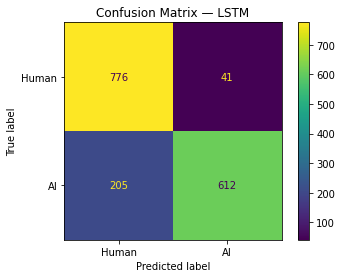

{'Model': 'LSTM',
 'Feature Set': 'Tokenized Sequences',
 'Accuracy': 0.8494492044063647,
 'Precision': 0.9372128637059725,
 'Recall': 0.7490820073439413,
 'F1': 0.8326530612244898,
 'AUC': 0.9503317657669265,
 'Training Time Seconds': 149.52030491828918}

In [25]:
# -----------------------------------------------------------------------------
# LSTM with RandomSearch-style tuning
# -----------------------------------------------------------------------------
# LSTM models process token sequences and can learn patterns related to word order.
# This cell randomly tests different LSTM sizes, dropout rates, learning rates,
# and batch sizes. The best validation result is kept for final test evaluation.

def build_lstm(max_words=MAX_WORDS, embed_dim=EMBED_DIM, lstm_units=64, dropout_rate=0.3, learning_rate=0.001):
    """Build an LSTM text classifier using tokenized and padded sequences."""
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embed_dim, input_length=MAX_LEN),
        LSTM(lstm_units),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_param_space = {
    'lstm_units': [32, 64, 128],
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [0.001, 0.0005],
    'batch_size': [32, 64]
}

lstm_trials = 3 if FAST_MODE else 6
lstm_param_list = list(ParameterSampler(lstm_param_space, n_iter=lstm_trials, random_state=RANDOM_STATE + 1))

best_lstm = None
best_lstm_val = -1
best_lstm_params = None
start = time.time()

for trial_number, params in enumerate(lstm_param_list, start=1):
    params = dict(params)
    print(f"LSTM RandomSearch trial {trial_number}/{len(lstm_param_list)}: {params}")

    batch_size = params.pop('batch_size')
    model = build_lstm(
        lstm_units=params['lstm_units'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.2,
        epochs=6,
        batch_size=batch_size,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    )

    val_acc = max(history.history['val_accuracy'])
    trial_params = dict(params)
    trial_params['batch_size'] = batch_size
    print('Validation accuracy:', val_acc)

    if val_acc > best_lstm_val:
        best_lstm_val = val_acc
        best_lstm = model
        best_lstm_params = trial_params

lstm_time = time.time() - start
print('Best LSTM parameters:', best_lstm_params)
print('Best LSTM validation accuracy:', best_lstm_val)
record_tuning_result('LSTM', 'RandomSearch-style Keras loop', best_lstm_params, best_lstm_val)
evaluate_keras_model('LSTM', best_lstm, X_test_pad, y_test, 'Tokenized Sequences', lstm_time)

### DL Model 3 — CNN for Text with Tuning

### Train the CNN for Text

The CNN looks for local phrase patterns in the tokenized text.

CNN RandomSearch trial 1/3: {'learning_rate': 0.0005, 'kernel_size': 5, 'filters': 64, 'dropout_rate': 0.4, 'batch_size': 64}
Validation accuracy: 0.9319051504135132
CNN RandomSearch trial 2/3: {'learning_rate': 0.0005, 'kernel_size': 5, 'filters': 64, 'dropout_rate': 0.4, 'batch_size': 32}
Validation accuracy: 0.9311400055885315
CNN RandomSearch trial 3/3: {'learning_rate': 0.001, 'kernel_size': 7, 'filters': 256, 'dropout_rate': 0.2, 'batch_size': 64}
Validation accuracy: 0.9426167011260986
Best CNN parameters: {'learning_rate': 0.001, 'kernel_size': 7, 'filters': 256, 'dropout_rate': 0.2, 'batch_size': 64}
Best CNN validation accuracy: 0.9426167011260986
CNN for Text (Tokenized Sequences)
              precision    recall  f1-score   support

       Human       0.92      0.98      0.95       817
          AI       0.98      0.91      0.94       817

    accuracy                           0.95      1634
   macro avg       0.95      0.95      0.95      1634
weighted avg       0.95    

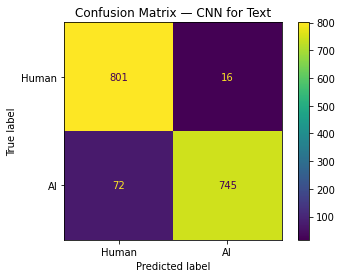

{'Model': 'CNN for Text',
 'Feature Set': 'Tokenized Sequences',
 'Accuracy': 0.9461444308445532,
 'Precision': 0.9789750328515112,
 'Recall': 0.9118727050183598,
 'F1': 0.944233206590621,
 'AUC': 0.9899548906423926,
 'Training Time Seconds': 101.75769805908203}

In [26]:
# -----------------------------------------------------------------------------
# CNN for Text with RandomSearch-style tuning
# -----------------------------------------------------------------------------
# A text CNN looks for local phrase patterns using convolution filters. This can
# be useful when AI-generated text repeats certain phrase structures or wording.
# The RandomSearch-style loop tests filter count, kernel size, dropout, learning
# rate, and batch size, then keeps the best validation model.

def build_cnn(max_words=MAX_WORDS, embed_dim=EMBED_DIM, filters=128, kernel_size=5, dropout_rate=0.3, learning_rate=0.001):
    """Build a CNN text classifier for tokenized and padded sequences."""
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embed_dim, input_length=MAX_LEN),
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_param_space = {
    'filters': [64, 128, 256],
    'kernel_size': [3, 5, 7],
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [0.001, 0.0005],
    'batch_size': [32, 64]
}

cnn_trials = 3 if FAST_MODE else 6
cnn_param_list = list(ParameterSampler(cnn_param_space, n_iter=cnn_trials, random_state=RANDOM_STATE + 2))

best_cnn = None
best_cnn_val = -1
best_cnn_params = None
start = time.time()

for trial_number, params in enumerate(cnn_param_list, start=1):
    params = dict(params)
    print(f"CNN RandomSearch trial {trial_number}/{len(cnn_param_list)}: {params}")

    batch_size = params.pop('batch_size')
    model = build_cnn(
        filters=params['filters'],
        kernel_size=params['kernel_size'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.2,
        epochs=6,
        batch_size=batch_size,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    )

    val_acc = max(history.history['val_accuracy'])
    trial_params = dict(params)
    trial_params['batch_size'] = batch_size
    print('Validation accuracy:', val_acc)

    if val_acc > best_cnn_val:
        best_cnn_val = val_acc
        best_cnn = model
        best_cnn_params = trial_params

cnn_time = time.time() - start
print('Best CNN parameters:', best_cnn_params)
print('Best CNN validation accuracy:', best_cnn_val)
record_tuning_result('CNN for Text', 'RandomSearch-style Keras loop', best_cnn_params, best_cnn_val)
evaluate_keras_model('CNN for Text', best_cnn, X_test_pad, y_test, 'Tokenized Sequences', cnn_time)

## IV. Evaluation & Comparison

This section creates the required accuracy table, compares feature sets, compares ML vs. DL, shows ROC curves, and provides the answers to the written analysis prompts.

### Hyperparameter Tuning Summary Table

This table documents the tuning method and best parameter set for each model. It is included so the submission clearly shows that all six required models were tuned, not only trained with default settings.

In [27]:
# Display the tuning method and selected parameters for each model.

tuning_df = pd.DataFrame(tuning_results)
tuning_df

,Model,Search Method,Best Parameters,Best Validation/CV Score
0,SVM,GridSearchCV,"{'svm__C': 2, 'svm__class_weight': None}",0.966872
1,Decision Tree,GridSearchCV,"{'tree__max_depth': 10, 'tree__min_samples_lea...",0.894109
2,AdaBoost,RandomizedSearchCV,"{'ada__n_estimators': 100, 'ada__learning_rate...",0.919762
3,SVM with Word2Vec,GridSearchCV,"{'svm__C': 2, 'svm__kernel': 'rbf'}",0.955443
4,FNN,RandomSearch-style Keras loop,"{'learning_rate': 0.001, 'hidden_units': 128, ...",0.942617
5,LSTM,RandomSearch-style Keras loop,"{'lstm_units': 32, 'learning_rate': 0.001, 'dr...",0.853864
6,CNN for Text,RandomSearch-style Keras loop,"{'learning_rate': 0.001, 'kernel_size': 7, 'fi...",0.942617


### Build the Final Results Table

This creates the comparison table and sorts the models by F1-score.

In [28]:
# Build the final comparison table.
# The upsert_result() helper prevents duplicate rows during normal execution.
# drop_duplicates is an additional safety check in case cells are rerun out of order.

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=['Model', 'Feature Set'], keep='last')
    .sort_values(by='F1', ascending=False)
    .reset_index(drop=True)
)
results_df

,Model,Feature Set,Accuracy,Precision,Recall,F1,AUC,Training Time Seconds
0,SVM,TF-IDF + Linguistic,0.971848,0.975339,0.968176,0.971744,0.995636,69.863874
1,SVM with Word2Vec,Word2Vec Embeddings,0.944920,0.948212,0.941248,0.944717,0.989066,8.997811
2,CNN for Text,Tokenized Sequences,0.946144,0.978975,0.911873,0.944233,0.989955,101.757698
3,AdaBoost,TF-IDF + Linguistic,0.934517,0.931873,0.937576,0.934716,0.983566,111.221675
4,FNN,TF-IDF/SVD Dense Features,0.922889,0.919806,0.926561,0.923171,0.980911,16.224119
5,Decision Tree,TF-IDF + Linguistic,0.906977,0.890717,0.927785,0.908873,0.923864,200.366812
6,LSTM,Tokenized Sequences,0.849449,0.937213,0.749082,0.832653,0.950332,149.520305


### Save the Results

The results are saved to CSV for reference.

In [29]:
# Save results for reference.

results_df.to_csv('model_comparison_results.csv', index=False)
results_df

,Model,Feature Set,Accuracy,Precision,Recall,F1,AUC,Training Time Seconds
0,SVM,TF-IDF + Linguistic,0.971848,0.975339,0.968176,0.971744,0.995636,69.863874
1,SVM with Word2Vec,Word2Vec Embeddings,0.944920,0.948212,0.941248,0.944717,0.989066,8.997811
2,CNN for Text,Tokenized Sequences,0.946144,0.978975,0.911873,0.944233,0.989955,101.757698
3,AdaBoost,TF-IDF + Linguistic,0.934517,0.931873,0.937576,0.934716,0.983566,111.221675
4,FNN,TF-IDF/SVD Dense Features,0.922889,0.919806,0.926561,0.923171,0.980911,16.224119
5,Decision Tree,TF-IDF + Linguistic,0.906977,0.890717,0.927785,0.908873,0.923864,200.366812
6,LSTM,Tokenized Sequences,0.849449,0.937213,0.749082,0.832653,0.950332,149.520305


### Model Performance Charts

These charts compare model accuracy and F1-score visually.

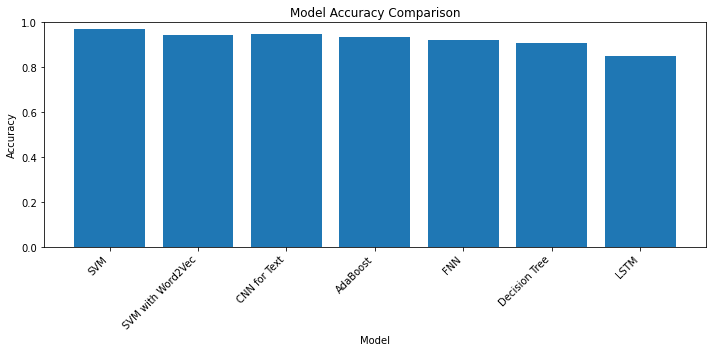

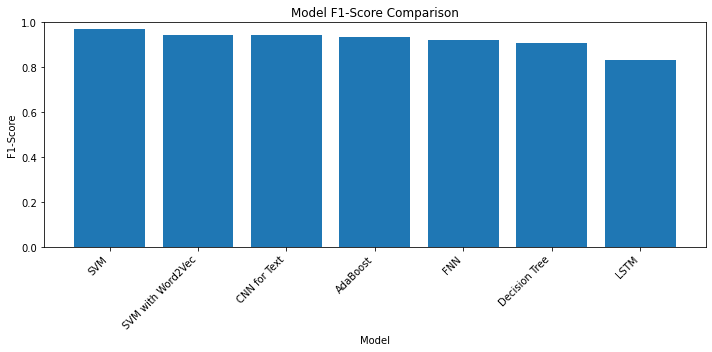

In [30]:
# Accuracy/F1 comparison chart

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['F1'])
plt.title('Model F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### ROC Curve Comparison

ROC curves show how well the models separate Human and AI text across thresholds.

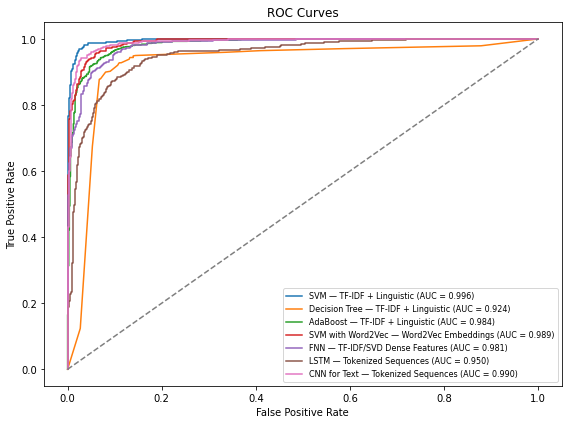

In [31]:
# ROC curves for every model.
# The diagonal dashed line represents random guessing.

plt.figure(figsize=(8, 6))
for name, data in roc_data.items():
    plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Feature Set Comparison

This groups results by feature set to support the written analysis about which features were most useful.

In [32]:
# Feature comparison: TF-IDF + linguistic vs Word2Vec embedding model

feature_comparison = results_df.groupby('Feature Set')[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].mean().sort_values('F1', ascending=False)
feature_comparison

,Accuracy,Precision,Recall,F1,AUC
Feature Set,,,,,
Word2Vec Embeddings,0.944920,0.948212,0.941248,0.944717,0.989066
TF-IDF + Linguistic,0.937780,0.932643,0.944512,0.938445,0.967689
TF-IDF/SVD Dense Features,0.922889,0.919806,0.926561,0.923171,0.980911
Tokenized Sequences,0.897797,0.958094,0.830477,0.888443,0.970143


### Traditional ML vs. Deep Learning

This groups models by model type to compare traditional ML against deep learning.

In [33]:
# ML vs DL comparison

model_type = {
    'SVM': 'Traditional ML',
    'Decision Tree': 'Traditional ML',
    'AdaBoost': 'Traditional ML',
    'SVM with Word2Vec': 'Traditional ML / Embedding Test',
    'FNN': 'Deep Learning',
    'LSTM': 'Deep Learning',
    'CNN for Text': 'Deep Learning'
}

results_df['Model Type'] = results_df['Model'].map(model_type)
results_df.groupby('Model Type')[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'Training Time Seconds']].mean()

,Accuracy,Precision,Recall,F1,AUC,Training Time Seconds
Model Type,,,,,,
Deep Learning,0.906161,0.945331,0.862505,0.900019,0.973732,89.167374
Traditional ML,0.937780,0.932643,0.944512,0.938445,0.967689,127.150787
Traditional ML / Embedding Test,0.944920,0.948212,0.941248,0.944717,0.989066,8.997811


## Written Analysis

### 1. Which model performed best overall? Why?

The Support Vector Machine (SVM) using TF-IDF and linguistic features performed the best overall. It achieved an accuracy of 97.18%, an F1-score of 0.9717, and an AUC of 0.9956, which were the highest values among all models tested.

One reason the SVM performed so well is that it combined two different types of information. The TF-IDF features captured important words and phrases, while the linguistic features measured writing characteristics such as sentence length, vocabulary diversity, and punctuation usage. By using both content and writing style, the model was able to separate human-written and AI-generated text more effectively than the other approaches.

### 2. Which features were most useful?

Based on the average results across feature sets, Word2Vec embeddings produced the strongest overall feature representation with an average F1-score of 0.9447 and an AUC of 0.9891.

Word2Vec was effective because it captures relationships between words and provides a representation of meaning rather than simply counting word occurrences. However, the highest-performing individual model still used TF-IDF combined with linguistic features, which suggests that writing style and word usage patterns remain very important when detecting AI-generated text. The results indicate that both semantic meaning and stylistic characteristics contribute to successful classification.

### 3. TF-IDF vs. Word Embeddings

The comparison between TF-IDF and Word2Vec produced interesting results. The Word2Vec feature set achieved a slightly higher average F1-score (0.9447) than the TF-IDF plus linguistic feature group (0.9384).

At the same time, the single best-performing model in the entire project was the SVM using TF-IDF and linguistic features. This suggests that while Word2Vec captures semantic meaning very well, TF-IDF remains extremely effective for AI text detection because it preserves important vocabulary and phrase-level patterns that often distinguish AI-generated writing from human writing.

### 4. Traditional Machine Learning vs. Deep Learning

The traditional machine learning models outperformed the deep learning models in this project. The best traditional model, the SVM, achieved an F1-score of 0.9717, while the best deep learning model, the CNN for Text, achieved an F1-score of 0.9442.

This result was somewhat surprising because deep learning models are often associated with superior text-processing performance. However, the dataset size and feature engineering likely favored the traditional approaches. TF-IDF combined with linguistic features provided highly informative inputs, allowing the machine learning models to achieve excellent results without requiring the larger datasets that deep learning models often need.

### 5. Speed vs. Accuracy Trade-Off

The results showed a clear trade-off between training speed and predictive performance. The fastest model was the SVM with Word2Vec embeddings, which completed training in approximately 9 seconds while still achieving an F1-score of 0.9447. The highest-performing model was the SVM with TF-IDF and linguistic features, which required about 70 seconds of training time but achieved the strongest overall results.

From a practical perspective, the Word2Vec SVM offers an attractive balance between speed and accuracy. However, if the goal is to maximize predictive performance, the TF-IDF plus linguistic feature SVM would still be the preferred choice.

### 6. Where Did the Models Fail?

The models struggled most with texts that shared characteristics of both human and AI writing. Highly polished human writing can resemble AI-generated content, while modern AI systems are becoming increasingly capable of mimicking natural human writing styles. Because of this overlap, some false positives and false negatives still occurred across all models.

Shorter documents may also present challenges because they provide fewer linguistic and stylistic clues. In addition, texts covering highly technical topics often contain repetitive vocabulary and structured language, making it more difficult to distinguish between human and AI authorship.

### 7. Would I Use This in a Real Classroom Setting?

As a college professor, I would use this type of tool as a supporting indicator rather than as definitive evidence of AI use. Throughout my teaching experience, I have reviewed student submissions that strongly appeared to be AI-generated based on writing style, sudden changes in quality, and inconsistencies with a student's previous work. However, I also recognize that no detection system can provide 100% proof that a student used AI.

For that reason, I would never rely solely on a model's prediction when making an academic integrity decision. Instead, I would use the results as a signal that additional review may be necessary. I would compare the submission to the student's previous writing, evaluate whether the work aligns with their demonstrated abilities, and, when appropriate, discuss the assignment directly with the student. Detection tools can help identify submissions that deserve closer attention, but they should not be used as the sole basis for accusing a student of cheating.
